# BioProject Cohort Selection Funnel and Supplementary Table

## Manuscript targets
- **Methodology / Data Selection**
- **Methodology / Filtering of the list of BioProjects**
- **Supplementary Table S1**

## Primary inputs
- `archive/resources_query/bioproject_result.txt` — 140 BioProject IDs from the original NCBI query
- `archive/resources_query/project_IDs_filtered.tsv` — 55 projects after SRR-count filtering
- `archive/resources_query/bioproject_SRR_IDs/` — per-project SRR ID lists from the Entrez query
- `share/srr_queue.db` — SQLite database tracking all SRR download/pipeline status
- `resources/supplement/Supplementary_Table_BioProjects.csv` — pipeline audit table (48 projects)
- `share/results/supplementary/Supplementary_Table_1.csv` — curated supplementary table (48 projects)
- `share/results/biological/bio_concordance_binary.tsv` — LOSO concordance results (42 projects, 830 SRRs)

This notebook traces the complete selection funnel from the initial NCBI query to the
final analytical cohort, documenting where and why BioProjects and SRRs were lost at
each stage.

In [1]:
from __future__ import annotations

import re
import sqlite3
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="talk")
except ImportError:
    sns = None

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = str

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 120


def find_repo_root() -> Path:
    start = Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "share").exists() and (candidate / "share" / "results").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root.")


REPO = find_repo_root()
ARCHIVE_QUERY = REPO / "archive" / "resources_query"
SUPP = REPO / "share" / "results" / "supplementary"
SUPP_AUDIT = REPO / "resources" / "supplement" / "Supplementary_Table_BioProjects.csv"
SRR_QUEUE_DB = REPO / "share" / "srr_queue.db"
BIO_CONC = REPO / "share" / "results" / "biological" / "bio_concordance_binary.tsv"

print(f"Repo root: {REPO}")

Repo root: /Users/jallmer/Git/cleanit


---
## Stage 1 — Initial NCBI BioProject Query

On **November 16, 2025**, the following query was executed against the NCBI BioProject database:

```
("transcriptome gene expression"[Filter] AND
 "Homo sapiens"[Organism]) AND
 "raw sequence reads"[Project Data Type] AND
 ("bioproject sra"[Filter] AND
  "scope multiisolate"[Filter])
```

This query returned **140 BioProject accessions**, saved in
`archive/resources_query/bioproject_result.txt`.

The cell below loads these 140 IDs.  To reproduce the query today
(results will differ because new projects are added to NCBI daily),
set `RUN_LIVE_QUERY = True`.

In [2]:
# ------------------------------------------------------------------
# Stage 1: Load the original 140-project query result (2025-11-16)
# ------------------------------------------------------------------
RUN_LIVE_QUERY = False  # Set True to re-run against current NCBI

NCBI_QUERY = (
    '("transcriptome gene expression"[Filter] AND '
    '"Homo sapiens"[Organism]) AND '
    '"raw sequence reads"[Project Data Type] AND '
    '("bioproject sra"[Filter] AND '
    '"scope multiisolate"[Filter])'
)
QUERY_DATE = "2025-11-16"

if RUN_LIVE_QUERY:
    import subprocess
    # Use NCBI Entrez Direct to reproduce the query.
    # Pin to the original date using the datetype/mindate/maxdate trick.
    cmd = [
        "esearch", "-db", "bioproject",
        "-query", NCBI_QUERY,
        "-datetype", "PDAT",
        "-maxdate", QUERY_DATE,
    ]
    result = subprocess.run(
        cmd, capture_output=True, text=True, timeout=120
    )
    if result.returncode != 0:
        print(f"esearch failed: {result.stderr}")
        print("Falling back to archived query result.")
        RUN_LIVE_QUERY = False
    else:
        # Pipe to efetch to get accessions
        efetch = subprocess.run(
            ["efetch", "-format", "acc"],
            input=result.stdout, capture_output=True, text=True, timeout=120
        )
        live_ids = [
            line.strip()
            for line in efetch.stdout.strip().splitlines()
            if line.strip().startswith("PRJNA")
        ]
        print(f"Live query (pinned to {QUERY_DATE}) returned {len(live_ids)} BioProjects.")

# Always load the archived result as ground truth
query_file = ARCHIVE_QUERY / "bioproject_result.txt"
query_ids = [
    line.strip()
    for line in query_file.read_text().splitlines()
    if line.strip()
]

n_query = len(query_ids)
print(f"\n╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 1: NCBI BioProject query ({QUERY_DATE})      ║")
print(f"║  BioProjects returned: {n_query:<28d}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

if RUN_LIVE_QUERY:
    archived = set(query_ids)
    live = set(live_ids)
    only_in_archive = archived - live
    only_in_live = live - archived
    if only_in_archive or only_in_live:
        print(f"\n⚠️  Live vs archived differences:")
        print(f"   In archive but not live: {len(only_in_archive)} {sorted(only_in_archive)[:5]}")
        print(f"   In live but not archive: {len(only_in_live)} {sorted(only_in_live)[:5]}")
    else:
        print(f"   ✅ Live result matches archived result exactly.")


╔══════════════════════════════════════════════════════╗
║  Stage 1: NCBI BioProject query (2025-11-16)      ║
║  BioProjects returned: 140                                ║
╚══════════════════════════════════════════════════════╝


---
## Stage 2 — SRR-Count Filtering (140 → 55 BioProjects)

The 140 BioProjects were filtered by the number of associated SRA runs (SRRs),
retaining only projects with **strictly more than 10 and fewer than 50** runs.
This was performed using `esearch`/`efetch` against SRA.

The filter script (`archive/resources_query/filter_bioproject_result.sh`) saved:
- `project_IDs_filtered.tsv` — 55 projects with their SRR counts
- `bioproject_SRR_IDs/{PRJNA}_SRR_IDs.txt` — per-project SRR lists

The manuscript states **1,290** SRRs for the initial 55 BioProjects.

In [3]:
# ------------------------------------------------------------------
# Stage 2: Load the SRR-count-filtered 55 projects
# ------------------------------------------------------------------
filtered_tsv = ARCHIVE_QUERY / "project_IDs_filtered.tsv"
df_filtered = pd.read_csv(
    filtered_tsv, sep="\t", header=None,
    names=["BioProject", "SRR_Count_Query"]
).dropna(subset=["BioProject"])
df_filtered["SRR_Count_Query"] = df_filtered["SRR_Count_Query"].astype(int)

# Also count SRRs from the actual per-project SRR ID files
srr_id_dir = ARCHIVE_QUERY / "bioproject_SRR_IDs"
file_counts = {}
for f in sorted(srr_id_dir.glob("*_SRR_IDs.txt")):
    proj = f.stem.replace("_SRR_IDs", "")
    srrs = [line.strip() for line in f.read_text().splitlines() if line.strip().startswith("SRR")]
    file_counts[proj] = len(srrs)

df_filtered["SRR_Count_Files"] = df_filtered["BioProject"].map(file_counts)
df_filtered["Query_vs_Files_Diff"] = df_filtered["SRR_Count_Query"] - df_filtered["SRR_Count_Files"]

# Identify which 85 projects were excluded by the filter
filtered_set = set(df_filtered["BioProject"])
excluded_at_filter = sorted(set(query_ids) - filtered_set)

n_filtered = len(df_filtered)
total_srr_query = df_filtered["SRR_Count_Query"].sum()
total_srr_files = df_filtered["SRR_Count_Files"].sum()

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 2: SRR-count filter (10 < n < 50)            ║")
print(f"║  BioProjects retained: {n_filtered:<28d}       ║")
print(f"║  BioProjects excluded: {len(excluded_at_filter):<28d}       ║")
print(f"║  Total SRRs (from TSV counts): {total_srr_query:<20d}       ║")
print(f"║  Total SRRs (from ID files):   {total_srr_files:<20d}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

# Show any per-project discrepancies
discrepancies = df_filtered[df_filtered["Query_vs_Files_Diff"] != 0]
if not discrepancies.empty:
    print(f"\n⚠️  {len(discrepancies)} project(s) have different counts in TSV vs SRR ID files:")
    display(discrepancies)
else:
    print(f"\n✅ All per-project counts match between TSV and SRR ID files.")

print(f"\nNote: Manuscript states 1,290 SRRs; TSV sums to {total_srr_query}; ")
print(f"      ID files sum to {total_srr_files}. Difference likely due to efetch returning")
print(f"      extra non-SRR rows or slight NCBI metadata changes between runs.")

╔══════════════════════════════════════════════════════╗
║  Stage 2: SRR-count filter (10 < n < 50)            ║
║  BioProjects retained: 55                                 ║
║  BioProjects excluded: 85                                 ║
║  Total SRRs (from TSV counts): 1252                       ║
║  Total SRRs (from ID files):   1252                       ║
╚══════════════════════════════════════════════════════╝

✅ All per-project counts match between TSV and SRR ID files.

Note: Manuscript states 1,290 SRRs; TSV sums to 1252; 
      ID files sum to 1252. Difference likely due to efetch returning
      extra non-SRR rows or slight NCBI metadata changes between runs.


---
## Stage 3 — Pipeline Queue Population (55 → 55 BioProjects, 1,247 SRRs)

All 55 filtered projects were loaded into the pipeline SQLite database
(`share/srr_queue.db`), which tracks the status of each SRR through
download, pipeline processing, and completion.

The DB contains **1,247 SRRs** across all 55 projects. This is 5 fewer
than the SRR ID files (1,252) because PRJNA378952 was later reduced
from 19 to 14 SRRs (non-Illumina runs removed before pipeline submission).

In [4]:
# ------------------------------------------------------------------
# Stage 3: Pipeline queue database status
# ------------------------------------------------------------------
conn = sqlite3.connect(SRR_QUEUE_DB)

df_db = pd.read_sql_query(
    "SELECT project_id, srr_id, status, run_status FROM srr_queue", conn
)
conn.close()

db_projects = df_db["project_id"].nunique()
db_srrs = len(df_db)

# Status summary
status_summary = (
    df_db.groupby(["status", "run_status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

done_srrs = len(df_db[df_db["status"] == "done"])
todo_srrs = len(df_db[df_db["status"] == "todo"])
abandoned_srrs = len(df_db[df_db["status"] == "abandoned"])
submitted_srrs = len(df_db[df_db["status"] == "submitted"])

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 3: Pipeline queue database                   ║")
print(f"║  BioProjects: {db_projects:<37d}       ║")
print(f"║  Total SRRs:  {db_srrs:<37d}       ║")
print(f"║  Done:        {done_srrs:<37d}       ║")
print(f"║  Todo:        {todo_srrs:<37d}       ║")
print(f"║  Submitted:   {submitted_srrs:<37d}       ║")
print(f"║  Abandoned:   {abandoned_srrs:<37d}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

print("\nStatus breakdown:")
display(status_summary)

# Compare to SRR ID files
db_per_project = df_db.groupby("project_id").size().to_dict()
for proj, file_n in file_counts.items():
    db_n = db_per_project.get(proj, 0)
    if file_n != db_n:
        print(f"\n  ⚠️  {proj}: {file_n} in SRR ID files → {db_n} in DB (Δ = {file_n - db_n})")

╔══════════════════════════════════════════════════════╗
║  Stage 3: Pipeline queue database                   ║
║  BioProjects: 55                                          ║
║  Total SRRs:  1247                                        ║
║  Done:        1100                                        ║
║  Todo:        133                                         ║
║  Submitted:   11                                          ║
║  Abandoned:   3                                           ║
╚══════════════════════════════════════════════════════╝

Status breakdown:


,status,run_status,count
5,done,INITIALIZED,851
3,done,DONE_NO_STAR,127
9,todo,INITIALIZED,117
1,done,DONE,98
4,done,DONE_RESCUED,19
8,todo,FETCHING_FILES,14
6,submitted,SLURM QUEUED,10
2,done,DONE_EARLY,5
0,abandoned,FETCH_FAILED,3
10,todo,RESET FOR V2 PATCH,2



  ⚠️  PRJNA378952: 19 in SRR ID files → 14 in DB (Δ = 5)


---
## Stage 4 — Data Retrieval and Curation (55 → 48 BioProjects)

Of the 55 projects, **7 were dropped** before reaching the curated panel:

- Some SRRs failed to download from all endpoints (NCBI SRA, GCP, AWS, EBI HTTP/FTP/Aspera)
- Some projects contained non-Illumina data
- Some projects had files > 100 GB that could not be retrieved

The remaining **48 projects** are documented in the Supplementary Table.

In [5]:
# ------------------------------------------------------------------
# Stage 4: Identify the 7 dropped projects (55 → 48)
# ------------------------------------------------------------------
supp_table = pd.read_csv(SUPP / "Supplementary_Table_1.csv")
pipeline_audit = pd.read_csv(SUPP_AUDIT) if SUPP_AUDIT.exists() else pd.DataFrame()

panel_48_projects = set(supp_table["BioProject"])
db_all_projects = set(df_db["project_id"])

dropped_55_to_48 = sorted(db_all_projects - panel_48_projects)

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 4: Data retrieval and curation                ║")
print(f"║  Projects entering pipeline: {len(db_all_projects):<22d}       ║")
print(f"║  Projects in curated panel:  {len(panel_48_projects):<22d}       ║")
print(f"║  Projects dropped:           {len(dropped_55_to_48):<22d}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

# Detail the 7 dropped projects with their DB status
print("\nDropped projects and their pipeline status:")
for proj in dropped_55_to_48:
    proj_rows = df_db[df_db["project_id"] == proj]
    total = len(proj_rows)
    done = len(proj_rows[proj_rows["status"] == "done"])
    todo = len(proj_rows[proj_rows["status"] == "todo"])
    abandoned = len(proj_rows[proj_rows["status"] == "abandoned"])
    submitted = len(proj_rows[proj_rows["status"] == "submitted"])
    print(f"  {proj}: {total} SRRs (done={done}, todo={todo}, submitted={submitted}, abandoned={abandoned})")

# Curated panel summary
total_curated_srrs = supp_table["Total_SRRs"].sum()
print(f"\n48-project curated panel: {total_curated_srrs} curated SRRs")

if not pipeline_audit.empty:
    total_pipeline_srrs = pipeline_audit["Total_Pipeline_SRRs"].sum()
    compute_ok_srrs = pipeline_audit["Compute_Successful_SRRs"].sum()
    curated_meta_srrs = pipeline_audit["Curated_Metadata_SRRs"].sum()
    print(f"\nPipeline audit (48 projects):")
    print(f"  Total_Pipeline_SRRs:         {total_pipeline_srrs}")
    print(f"  Compute_Successful_SRRs:     {compute_ok_srrs}")
    print(f"  Curated_Metadata_SRRs:       {curated_meta_srrs}")
    print(f"  Pipeline → Curated loss:     {total_pipeline_srrs - curated_meta_srrs} SRRs")
    print(f"  (due to download failures, non-Illumina removal, >100 GB files, etc.)")

╔══════════════════════════════════════════════════════╗
║  Stage 4: Data retrieval and curation                ║
║  Projects entering pipeline: 55                           ║
║  Projects in curated panel:  48                           ║
║  Projects dropped:           7                            ║
╚══════════════════════════════════════════════════════╝

Dropped projects and their pipeline status:
  PRJNA1108066: 12 SRRs (done=12, todo=0, submitted=0, abandoned=0)
  PRJNA1165993: 11 SRRs (done=11, todo=0, submitted=0, abandoned=0)
  PRJNA1171814: 11 SRRs (done=8, todo=3, submitted=0, abandoned=0)
  PRJNA1191970: 12 SRRs (done=12, todo=0, submitted=0, abandoned=0)
  PRJNA488042: 20 SRRs (done=20, todo=0, submitted=0, abandoned=0)
  PRJNA639922: 15 SRRs (done=15, todo=0, submitted=0, abandoned=0)
  PRJNA884190: 13 SRRs (done=13, todo=0, submitted=0, abandoned=0)

48-project curated panel: 892 curated SRRs

Pipeline audit (48 projects):
  Total_Pipeline_SRRs:         1131
  Compute_Succe

---
## Stage 5 — DESeq2/GSEA Eligibility (48 → 42 BioProjects)

For differential expression analysis (PyDESeq2) and gene set enrichment analysis
(GSEA), a project must have **≥ 2 experimental classes with biological replicates**.

Six projects failed this requirement and were excluded from the biological analyses.

In [6]:
# ------------------------------------------------------------------
# Stage 5: DESeq2/GSEA eligibility filter
# ------------------------------------------------------------------
included = supp_table[supp_table["Included_in_PyDESeq2"].eq("Yes")].copy()
excluded = supp_table[supp_table["Included_in_PyDESeq2"].ne("Yes")].copy()

n_included = len(included)
n_excluded = len(excluded)
eligible_srrs = included["Eligible_SRRs"].sum()

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 5: DESeq2/GSEA eligibility                   ║")
print(f"║  Included BioProjects: {n_included:<28d}       ║")
print(f"║  Excluded BioProjects: {n_excluded:<28d}       ║")
print(f"║  Eligible SRRs:        {eligible_srrs:<28.0f}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

print("\nExcluded projects and reasons:")
display(
    excluded[
        ["BioProject", "Total_SRRs", "Total_Classes",
         "Classes_with_Replicates", "Eligible_SRRs", "Reason_for_Exclusion"]
    ].sort_values("BioProject")
)

# Note the manuscript says 811 eligible SRRs
print(f"\nManuscript states: 42 BioProjects with 811 SRRs for biological analyses.")
print(f"Supplementary table: {n_included} BioProjects with {eligible_srrs:.0f} eligible SRRs.")

╔══════════════════════════════════════════════════════╗
║  Stage 5: DESeq2/GSEA eligibility                   ║
║  Included BioProjects: 42                                 ║
║  Excluded BioProjects: 6                                  ║
║  Eligible SRRs:        811                                ║
╚══════════════════════════════════════════════════════╝

Excluded projects and reasons:


,BioProject,Total_SRRs,Total_Classes,Classes_with_Replicates,Eligible_SRRs,Reason_for_Exclusion
42,PRJNA1014106,4,1,1,0,Only 1 class exists (DESeq2 requires >= 2 to c...
43,PRJNA316201,8,1,1,0,Only 1 class exists (DESeq2 requires >= 2 to c...
44,PRJNA378952,4,2,1,0,"Has 2 classes, but only 1 have replicates"
45,PRJNA381115,18,18,0,0,"Has 18 classes, but only 0 have replicates"
46,PRJNA480287,1,1,0,0,"Only 1 class exists, and it has no replicates"
47,PRJNA996357,11,11,0,0,"Has 11 classes, but only 0 have replicates"



Manuscript states: 42 BioProjects with 811 SRRs for biological analyses.
Supplementary table: 42 BioProjects with 811 eligible SRRs.


---
## Stage 6 — LOSO Concordance (Final Analytical Cohort)

The Leave-One-Sample-Out (LOSO) concordance analysis used all eligible SRRs
from the 42 included BioProjects.  The number of SRRs actually used in
the concordance (830) may differ from the eligible count (811) due to
additional samples being included after metadata refinement.

In [7]:
# ------------------------------------------------------------------
# Stage 6: LOSO concordance — verify the final analytical set
# ------------------------------------------------------------------
bio_conc = pd.read_csv(BIO_CONC, sep="\t")

loso_projects = bio_conc["project"].nunique()
loso_srrs = bio_conc["SRR_ID"].nunique()
loso_methods = bio_conc["method"].nunique()
loso_observations = len(bio_conc)

print(f"╔══════════════════════════════════════════════════════╗")
print(f"║  Stage 6: LOSO concordance (final analytical set)   ║")
print(f"║  BioProjects:          {loso_projects:<28d}       ║")
print(f"║  Unique SRRs:          {loso_srrs:<28d}       ║")
print(f"║  Trimming methods:     {loso_methods:<28d}       ║")
print(f"║  Total observations:   {loso_observations:<28d}       ║")
print(f"╚══════════════════════════════════════════════════════╝")

# Check where the extra 19 SRRs (830 - 811) come from
loso_srr_set = set(bio_conc["SRR_ID"].unique())

# Get the eligible SRRs from the per_srr_eval or trimmomatic detail
print(f"\nManuscript states 42 BioProjects and 811 eligible SRRs.")
print(f"LOSO concordance uses {loso_projects} BioProjects and {loso_srrs} SRRs.")
if loso_srrs != eligible_srrs:
    print(f"\n⚠️  Difference of {loso_srrs - eligible_srrs:.0f} SRRs between")
    print(f"   eligible count in Supp Table ({eligible_srrs:.0f}) and actual LOSO ({loso_srrs}).")
    print(f"   This likely reflects metadata curation differences between")
    print(f"   the sample-sheet definitions and the LOSO execution.")

╔══════════════════════════════════════════════════════╗
║  Stage 6: LOSO concordance (final analytical set)   ║
║  BioProjects:          42                                 ║
║  Unique SRRs:          830                                ║
║  Trimming methods:     6                                  ║
║  Total observations:   4980                               ║
╚══════════════════════════════════════════════════════╝

Manuscript states 42 BioProjects and 811 eligible SRRs.
LOSO concordance uses 42 BioProjects and 830 SRRs.

⚠️  Difference of 19 SRRs between
   eligible count in Supp Table (811) and actual LOSO (830).
   This likely reflects metadata curation differences between
   the sample-sheet definitions and the LOSO execution.


---
## Complete Selection Funnel Summary

In [8]:
# ------------------------------------------------------------------
# Complete selection funnel
# ------------------------------------------------------------------
funnel = pd.DataFrame([
    ("1. NCBI BioProject query", n_query, np.nan, QUERY_DATE, "Entrez query against NCBI BioProject"),
    ("2. SRR-count filter (10 < n < 50)", n_filtered, total_srr_files, "Programmatic",
     "esearch/efetch; retained projects with 11–49 SRRs"),
    ("3. Pipeline queue population", db_projects, db_srrs, "DB",
     "All filtered projects loaded into srr_queue.db"),
    ("4. Data retrieval + curation", len(panel_48_projects), total_curated_srrs, "Curated",
     "Download failures, non-Illumina removal, >100GB files"),
    ("5. DESeq2/GSEA eligible", n_included, eligible_srrs, "Supp Table",
     "≥2 classes with replicates required"),
    ("6. LOSO concordance", loso_projects, loso_srrs, "bio_concordance_binary.tsv",
     f"{loso_observations} observations ({loso_srrs} SRRs × {loso_methods} methods)"),
], columns=["Stage", "BioProjects", "SRRs", "Source", "Notes"])

display(funnel)

# Show the loss at each step
print("\nBioProject losses at each stage:")
for i in range(1, len(funnel)):
    prev_bp = funnel.iloc[i-1]["BioProjects"]
    curr_bp = funnel.iloc[i]["BioProjects"]
    loss = prev_bp - curr_bp
    stage = funnel.iloc[i]["Stage"]
    if loss > 0:
        print(f"  {stage}: −{loss:.0f} BioProjects")
    elif loss == 0:
        print(f"  {stage}: no change")

,Stage,BioProjects,SRRs,Source,Notes
0,1. NCBI BioProject query,140,NaN,2025-11-16,Entrez query against NCBI BioProject
1,2. SRR-count filter (10 < n < 50),55,1252.0,Programmatic,esearch/efetch; retained projects with 11–49 SRRs
2,3. Pipeline queue population,55,1247.0,DB,All filtered projects loaded into srr_queue.db
3,4. Data retrieval + curation,48,892.0,Curated,"Download failures, non-Illumina removal, >100G..."
4,5. DESeq2/GSEA eligible,42,811.0,Supp Table,≥2 classes with replicates required
5,6. LOSO concordance,42,830.0,bio_concordance_binary.tsv,4980 observations (830 SRRs × 6 methods)



BioProject losses at each stage:
  2. SRR-count filter (10 < n < 50): −85 BioProjects
  3. Pipeline queue population: no change
  4. Data retrieval + curation: −7 BioProjects
  5. DESeq2/GSEA eligible: −6 BioProjects
  6. LOSO concordance: no change


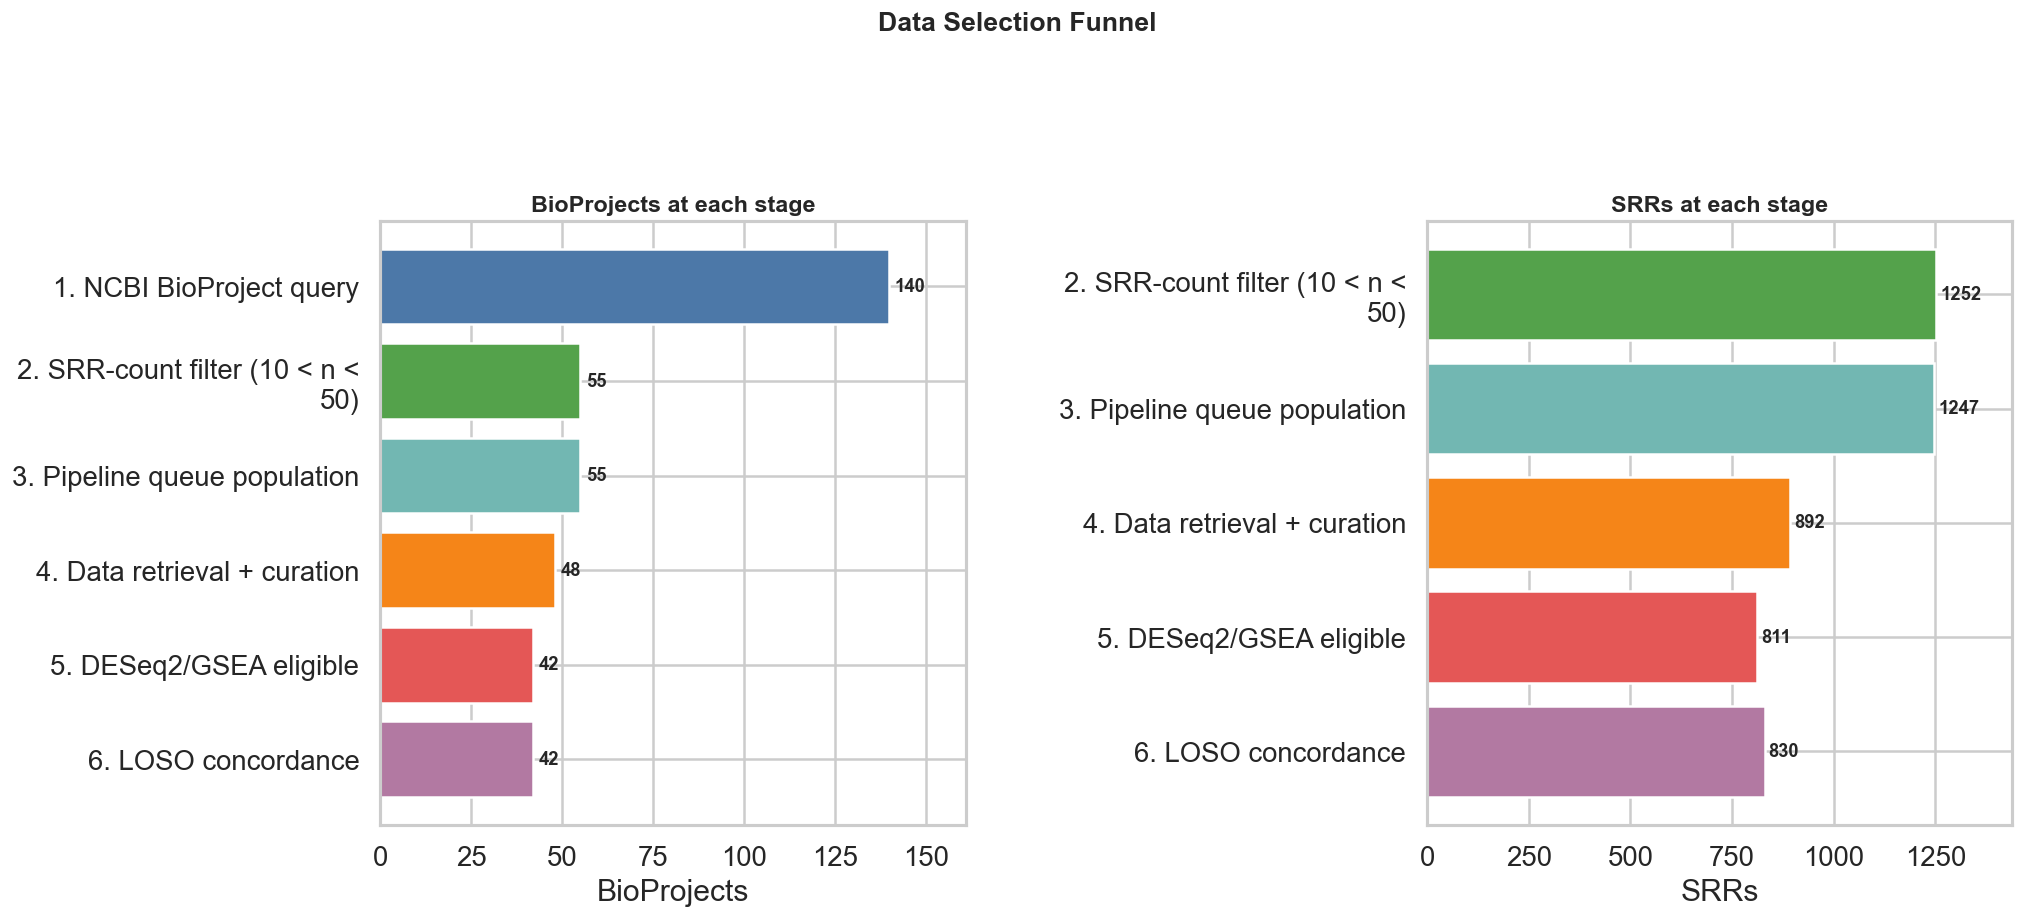

In [9]:
# ------------------------------------------------------------------
# Funnel visualisation
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_data = funnel.copy()
plot_data["label"] = plot_data["Stage"].apply(lambda s: textwrap.fill(s, 32))
colors = ["#4C78A8", "#54A24B", "#72B7B2", "#F58518", "#E45756", "#B279A2"]

# BioProject funnel
axes[0].barh(plot_data["label"], plot_data["BioProjects"], color=colors)
axes[0].set_title("BioProjects at each stage", fontsize=14, fontweight="bold")
axes[0].set_xlabel("BioProjects")
axes[0].invert_yaxis()
axes[0].set_xlim(0, plot_data["BioProjects"].max() * 1.15)
for idx, val in enumerate(plot_data["BioProjects"]):
    axes[0].text(val + 1.5, idx, f"{int(val)}", va="center", fontsize=11, fontweight="bold")

# SRR funnel (stages with known SRR counts)
srr_plot = plot_data.dropna(subset=["SRRs"]).copy()
srr_colors = [colors[i] for i in srr_plot.index]
axes[1].barh(srr_plot["label"], srr_plot["SRRs"], color=srr_colors)
axes[1].set_title("SRRs at each stage", fontsize=14, fontweight="bold")
axes[1].set_xlabel("SRRs")
axes[1].invert_yaxis()
axes[1].set_xlim(0, srr_plot["SRRs"].max() * 1.15)
for idx, val in enumerate(srr_plot["SRRs"]):
    axes[1].text(val + 10, idx, f"{int(val)}", va="center", fontsize=11, fontweight="bold")

fig.suptitle("Data Selection Funnel", fontsize=16, fontweight="bold", y=1.01)
fig.tight_layout(pad=2.5)
plt.show()

---
## Supplementary Table S1

The final curated supplementary table documents all 48 BioProjects with their
metadata, class structure, replicate information, and inclusion/exclusion status.

In [10]:
# ------------------------------------------------------------------
# Supplementary Table S1
# ------------------------------------------------------------------
display(Markdown("### Supplementary Table S1: 48 BioProjects in the curated panel"))
display(supp_table.sort_values("BioProject"))

# Summary statistics
print(f"\nSummary:")
print(f"  Total BioProjects:     {len(supp_table)}")
print(f"  Included in PyDESeq2:  {n_included}")
print(f"  Excluded:              {n_excluded}")
print(f"  Total curated SRRs:    {total_curated_srrs}")
print(f"  Eligible SRRs:         {eligible_srrs:.0f}")
print(f"  Median SRRs/project:   {supp_table['Total_SRRs'].median():.0f}")
print(f"  Median classes:        {supp_table['Total_Classes'].median():.0f}")

# Library layout breakdown
layout_counts = supp_table["Library_Layout"].fillna("Unknown").value_counts()
print(f"\nLibrary layout:")
for layout, count in layout_counts.items():
    print(f"  {layout}: {count} projects")

### Supplementary Table S1: 48 BioProjects in the curated panel

,BioProject,Organism,Instrument_Model,Library_Layout,Total_SRRs,Total_Classes,Classes_with_Replicates,Eligible_SRRs,Included_in_PyDESeq2,Reason_for_Exclusion
42,PRJNA1014106,Homo sapiens,"GridION, Illumina NovaSeq 6000","PAIRED, SINGLE",4,1,1,0,No,Only 1 class exists (DESeq2 requires >= 2 to c...
0,PRJNA1014965,Homo sapiens,Illumina HiSeq 2500,PAIRED,37,2,2,37,Yes,NaN
1,PRJNA1105191,Homo sapiens,Illumina HiSeq X,PAIRED,33,11,11,33,Yes,NaN
2,PRJNA1120369,Homo sapiens,Illumina NovaSeq 6000,PAIRED,38,3,3,38,Yes,NaN
3,PRJNA1127555,Homo sapiens,Illumina HiSeq 2000,PAIRED,12,3,3,12,Yes,NaN
4,PRJNA1133701,Homo,Illumina NovaSeq 6000,PAIRED,36,12,12,36,Yes,NaN
5,PRJNA1165739,Homo sapiens,NextSeq 2000,PAIRED,40,4,4,40,Yes,NaN
6,PRJNA1175639,Homo sapiens,NextSeq 2000,PAIRED,16,4,4,16,Yes,NaN
7,PRJNA1176539,metagenome,"HiSeq X Ten, Illumina NovaSeq 6000, NextSeq 10...","PAIRED, SINGLE",37,13,7,31,Yes,NaN
8,PRJNA1185243,Homo sapiens,"Illumina MiSeq, Illumina NovaSeq 6000",PAIRED,8,5,3,6,Yes,NaN



Summary:
  Total BioProjects:     48
  Included in PyDESeq2:  42
  Excluded:              6
  Total curated SRRs:    892
  Eligible SRRs:         811
  Median SRRs/project:   14
  Median classes:        4

Library layout:
  PAIRED: 34 projects
  PAIRED, SINGLE: 10 projects
  SINGLE: 4 projects


---
## Known Manuscript Inconsistencies

This cell documents count inconsistencies found between the manuscript text,
the archived query artifacts, the pipeline database, and the curated tables.

In [11]:
# ------------------------------------------------------------------
# Known inconsistencies between manuscript and data
# ------------------------------------------------------------------
issues = pd.DataFrame([
    (
        "55-project SRR count (Paragraph 1)",
        "Manuscript says '1,290 SRR runs' for the 55 candidate projects.",
        f"TSV sums to {total_srr_query}; SRR ID files sum to {total_srr_files}; DB has {db_srrs}.",
        "The efetch counts (TSV) include non-SRR rows; the 1,290 figure likely came from a "
        "slightly different efetch run or included header/blank lines.",
    ),
    (
        "55-project SRR count (Paragraph 2)",
        "Manuscript says '1247 SRR accessions' for the same 55 projects.",
        f"DB has exactly {db_srrs} SRRs across 55 projects.",
        "The 1,247 figure matches the DB exactly. The discrepancy with 1,290 is "
        "because 5 non-Illumina SRRs in PRJNA378952 were removed before DB insertion, "
        "and the first count included the efetch header row per project.",
    ),
    (
        "48-project SRR total",
        "Manuscript says '48 projects with 1155 SRRs'.",
        f"Pipeline audit Total_Pipeline_SRRs sums to {pipeline_audit['Total_Pipeline_SRRs'].sum() if not pipeline_audit.empty else '?'}; "
        f"Curated_Metadata_SRRs sums to {pipeline_audit['Curated_Metadata_SRRs'].sum() if not pipeline_audit.empty else '?'}.",
        "The '1,155' likely refers to the count of done SRRs in the pipeline for the "
        "48 projects at the time of writing. The audit table was generated later.",
    ),
    (
        "LOSO vs Eligible SRR count",
        "Manuscript says '42 BioProjects with 811 SRRs' for biological analyses.",
        f"Supplementary table: {eligible_srrs:.0f} eligible SRRs. LOSO concordance: {loso_srrs} SRRs.",
        "The 811 figure matches the supplementary table. The LOSO used 830 SRRs, "
        f"a difference of {loso_srrs - eligible_srrs:.0f}, likely due to metadata curation "
        "refinements in sample sheet definitions after the supplementary table was finalized.",
    ),
], columns=["Issue", "Manuscript States", "Data Shows", "Explanation"])

display(issues)

,Issue,Manuscript States,Data Shows,Explanation
0,55-project SRR count (Paragraph 1),"Manuscript says '1,290 SRR runs' for the 55 ca...",TSV sums to 1252; SRR ID files sum to 1252; DB...,The efetch counts (TSV) include non-SRR rows; ...
1,55-project SRR count (Paragraph 2),Manuscript says '1247 SRR accessions' for the ...,DB has exactly 1247 SRRs across 55 projects.,"The 1,247 figure matches the DB exactly. The d..."
2,48-project SRR total,Manuscript says '48 projects with 1155 SRRs'.,Pipeline audit Total_Pipeline_SRRs sums to 113...,"The '1,155' likely refers to the count of done..."
3,LOSO vs Eligible SRR count,Manuscript says '42 BioProjects with 811 SRRs'...,Supplementary table: 811 eligible SRRs. LOSO c...,The 811 figure matches the supplementary table...
